I downloaded the data from the scDesign3 [quickstart](https://songdongyuan1994.github.io/scDesign3/docs/articles/scDesign3.html). There are only 100 genes in this demo.

In [1]:
from scdesigner.datasets import pancreas

example_sce = pancreas()

The result seems quite sensitive to the learning rate. How can we pick a good default? Maybe we can systematically survey good lr's across a range of public data. Alternatively, is there a good way to adapt during learning?

In [2]:
from scdesigner.simulators import NegBinCopula

sim = NegBinCopula("~ pseudotime")
sim.fit(example_sce)
sim

Epoch 264/500, Loss: 2.0489, Val Loss: 2.0596


Estimating copula correlation: 100%|██████████| 3/3 [00:02<00:00,  1.41it/s]


In [3]:
sim.predict()

{'mean': array([[3.41867676e+01, 7.01691866e+00, 2.37803860e+01, ...,
         9.10366952e-01, 1.58669408e-02, 1.31455922e+00],
        [5.53781128e+00, 2.70111412e-01, 7.30114269e+00, ...,
         1.91593719e+00, 1.13358496e-04, 1.48487866e+00],
        [5.83421173e+01, 1.82609482e+01, 3.36359024e+01, ...,
         7.31684804e-01, 6.77087978e-02, 1.26836348e+00],
        ...,
        [4.01744270e+01, 9.36640167e+00, 2.64051704e+01, ...,
         8.52242112e-01, 2.45907903e-02, 1.30043542e+00],
        [1.80078430e+01, 2.22826815e+00, 1.56897840e+01, ...,
         1.18310952e+00, 2.78436160e-03, 1.37218821e+00],
        [2.53916717e+00, 6.69187680e-02, 4.40253687e+00, ...,
         2.63523984e+00, 1.36497038e-05, 1.56443369e+00]],
       shape=(2087, 100), dtype=float32),
 'dispersion': array([[0.33245692, 0.55337447, 0.32255208, ..., 4.3984776 , 0.15175341,
         0.65125746],
        [0.33245692, 0.55337447, 0.32255208, ..., 4.3984776 , 0.15175341,
         0.65125746],
        [0

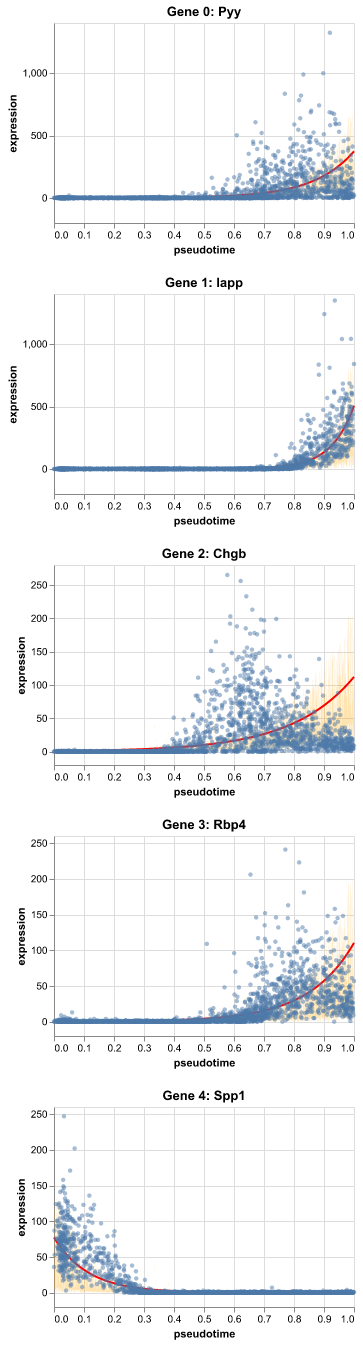

In [4]:
import altair as alt
import scipy.sparse
import pandas as pd
import numpy as np
alt.data_transformers.enable("vegafusion")
alt.renderers.enable('png')


def visualize_gene_expression(sim, sce, num_genes=5):
    """Visualize gene expression with confidence bands using Altair"""
    charts = []

    if scipy.sparse.issparse(sce.X):
        sce.X = sce.X.todense()

    for ix in range(num_genes):
        gene = sce.var_names[ix]

        # Get predictions
        predictions = sim.predict(sce.obs)
        y_hat = pd.DataFrame({
            'pseudotime': sce.obs['pseudotime'],
            'mean': predictions['mean'][:, ix],
            'dispersion': predictions.get('dispersion', np.zeros_like(predictions['mean']))[:, ix]
        })

        # Calculate variance and confidence bands
        variance = y_hat['mean'] + (y_hat['mean'] ** 2) * y_hat['dispersion']
        y_hat['lower_sd'] = y_hat['mean'] - np.sqrt(variance)
        y_hat['upper_sd'] = y_hat['mean'] + np.sqrt(variance)

        # Prepare data for plotting
        plot_data = pd.DataFrame({
            'pseudotime': sce.obs['pseudotime'],
            'expression': sce.X[:, ix],
            'type': 'observed'
        })

        prediction_data = pd.DataFrame({
            'pseudotime': y_hat['pseudotime'],
            'expression': y_hat['mean'],
            'type': 'predicted'
        })

        confidence_data = pd.DataFrame({
            'pseudotime': pd.concat([y_hat['pseudotime'], y_hat['pseudotime'][::-1]]),
            'expression': pd.concat([y_hat['lower_sd'], y_hat['upper_sd'][::-1]]),
            'type': 'confidence'
        })

        # Combine all data
        combined_data = pd.concat([plot_data, prediction_data, confidence_data])

        # Create chart
        base = alt.Chart(combined_data).encode(
            x='pseudotime:Q',
            y='expression:Q'
        ).properties(
            title=f'Gene: {gene}',
            width=300,
            height=200
        )

        points = base.mark_circle(size=20, opacity=0.5).transform_filter(
            alt.datum.type == 'observed'
        )

        line = base.mark_line(color='red').transform_filter(
            alt.datum.type == 'predicted'
        )

        band = base.mark_area(opacity=0.3, color='orange').transform_filter(
            alt.datum.type == 'confidence'
        )

        chart = (band + line + points).properties(title=f'Gene {ix}: {gene}')
        charts.append(chart)

    # Display charts
    return alt.vconcat(*charts)

# Visualize the first 5 genes
visualize_gene_expression(sim, example_sce, num_genes=5)

In [5]:
sim = NegBinCopula("~ bs(pseudotime, df=10)")
sim.fit(example_sce)

Epoch 116/500, Loss: 1.8566, Val Loss: 1.8669


Estimating copula correlation: 100%|██████████| 3/3 [00:01<00:00,  2.54it/s]


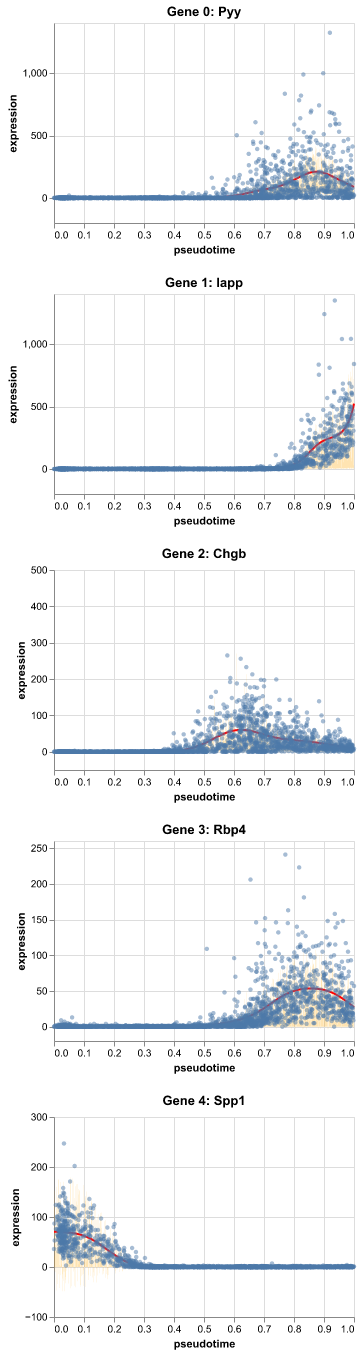

In [6]:
# Visualize with the more complex model
visualize_gene_expression(sim, example_sce, num_genes=5)

In [7]:
fmla = {"mean_formula": "~ bs(pseudotime, df=10)", "dispersion_formula": "~ bs(pseudotime, df=4)"}
sim = NegBinCopula(**fmla)
sim.fit(example_sce)

Epoch 213/500, Loss: 1.8375, Val Loss: 1.8476


Estimating copula correlation: 100%|██████████| 3/3 [00:01<00:00,  2.39it/s]


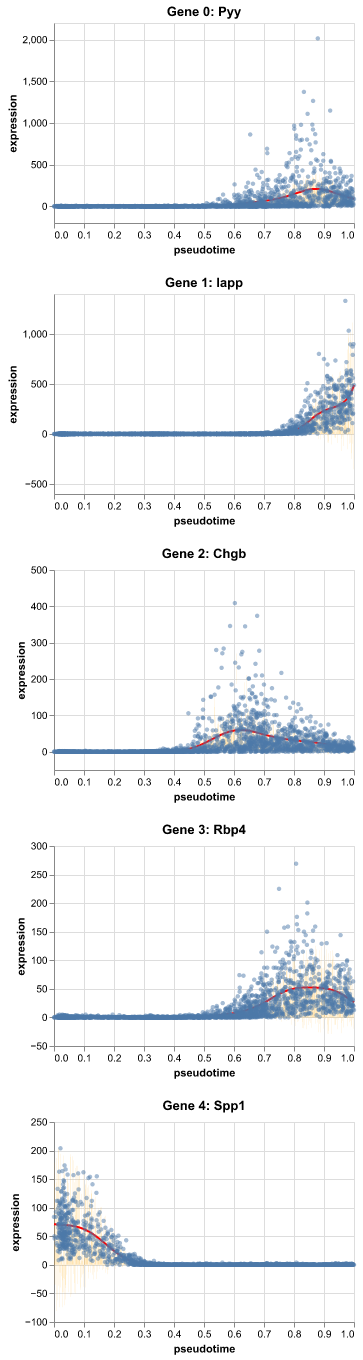

In [8]:
# Visualize with custom formulas
visualize_gene_expression(sim, sim.sample(), num_genes=5)

Here is a version of a copula that has a different covariance for each cell type.

In [9]:
sim = NegBinCopula(mean_formula="~ pseudotime", copula_formula="~ cell_type")
sim.fit(example_sce)

print(sim.parameters["copula"]["cell_type[T.Ngn3 high EP]"].to_full_matrix()[:2, :2])
print(sim.parameters["copula"]["cell_type[T.Beta]"].to_full_matrix()[:2, :2])

sim.sample()

Epoch 264/500, Loss: 2.0489, Val Loss: 2.0596


Estimating copula correlation: 100%|██████████| 3/3 [00:00<00:00,  4.17it/s]


[[1.         0.10279859]
 [0.10279859 1.        ]]
[[1.         0.07114692]
 [0.07114692 1.        ]]


AnnData object with n_obs × n_vars = 2087 × 100
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'cell_type', 'sizeFactor', 'pseudotime'
    var: 'highly_variable_genes'

# Poisson

In [ ]:
from scdesigner.simulators import PoissonCopula

sim = PoissonCopula("~ pseudotime")
sim.fit(example_sce)
sim

In [ ]:
# Visualize Poisson model
visualize_gene_expression(sim, example_sce, num_genes=5)

In [ ]:
# Compare real vs simulated data
sampled = sim.sample(example_sce.obs)
visualize_gene_expression(sim, sampled, num_genes=5)

In [ ]:
# plotting correlation of simulated data, compare with real by substituting sampled = example_sce
sampled = sim.sample()
X = pd.DataFrame(np.log(1 + sampled.X), columns=sampled.var_names, index=sampled.obs.index)

sampled_subset = pd.concat([X.iloc[:, :5], sampled.obs], axis=1)
alt.Chart(sampled_subset).mark_circle(opacity=1, size=1).encode(
    alt.X(alt.repeat("column"), type='quantitative'),
    alt.Y(alt.repeat("row"), type='quantitative')
).properties(width=40, height=40).repeat(
    row=sampled_subset.columns[:5],
    column=sampled_subset.columns[:5]
).configure_axis(labelFontSize=9, titleFontSize=9)

# Bernoulli

In [ ]:
from scdesigner.simulators import BernoulliCopula
from scdesigner.datasets import scgemmeth

multi = scgemmeth()
multi.X

In [ ]:
sim = BernoulliCopula("~ bs(X2, df=3)")
sim.fit(multi)
sim

In [ ]:
# Visualize Bernoulli model
def visualize_bernoulli_expression(sim, sce, num_genes=5, var="X2"):
    """Visualize Bernoulli expression probabilities"""
    charts = []

    for ix in range(num_genes):
        gene = sce.var_names[ix]

        # Get predictions
        predictions = sim.predict(sce.obs)
        y_hat = pd.DataFrame({ var: sce.obs[var], 'probability': predictions['mean'][:, ix] })

        # Prepare data for plotting
        plot_data = pd.DataFrame({var: sce.obs[var], 'expression': sce.X[:, ix], 'type': 'observed'})
        prediction_data = pd.DataFrame({var: y_hat[var], 'expression': y_hat['probability'], 'type': 'predicted'})
        combined_data = pd.concat([plot_data, prediction_data])

        # Create chart
        base = alt.Chart(combined_data).encode(
            x=f'{var}:Q',
            y='expression:Q'
        ).properties(
            title=f'Gene {ix}: {gene}',
            width=300,
            height=200
        )

        points_obs = base.mark_circle(size=20, opacity=0.5).transform_filter(
            alt.datum.type == 'observed'
        )

        points_pred = base.mark_circle(size=20, color='red').transform_filter(
            alt.datum.type == 'predicted'
        )

        chart = (points_obs + points_pred)
        charts.append(chart)

    # Display charts
    return alt.vconcat(*charts)

# Visualize Bernoulli genes
visualize_bernoulli_expression(sim, multi, num_genes=5)

In [ ]:
# Compare real vs simulated Bernoulli data
def compare_bernoulli_data(sim, sce, num_genes=5, var="X2"):
    """Compare real vs simulated Bernoulli data with jitter"""
    charts = []

    for ix in range(num_genes):
        gene = sce.var_names[ix]
        sampled = sim.sample(sce.obs)

        # Add jitter to avoid overplotting
        jitter_real = sce.X[:, ix] + np.random.normal(0, 0.1, sce.X.shape[0])
        jitter_sim = sampled.X[:, ix] + np.random.normal(0, 0.1, sampled.X.shape[0])

        # Prepare data for plotting
        real_data = pd.DataFrame({ var: sce.obs[var], 'expression': jitter_real, 'type': 'real' })
        sim_data = pd.DataFrame({ var: sce.obs[var], 'expression': jitter_sim, 'type': 'simulated' })
        combined_data = pd.concat([real_data, sim_data])

        # Create chart
        chart = alt.Chart(combined_data).mark_circle(size=20, opacity=0.5).encode(
            x=f'{var}:Q',
            y='expression:Q',
            color='type:N'
        ).properties(
            title=f'Gene {ix}: {gene}',
            width=300,
            height=200
        )

        charts.append(chart)

    # Display charts
    return alt.vconcat(*charts)

compare_bernoulli_data(sim, multi, num_genes=5)